# Examen Bewegingen: Nokken
## Specificaties (Opgave 50)
De te ontwerpen nok moet volgende heffing kunnen realiseren :
- van 0° tot 120° : +10 mm
- van 120° tot 180° : +30 mm
- van 200° tot 240° : -40 mm

De equivalente massa en dempingsconstante van de volger (en bijhorende onderdelen) worden respectievelijk geschat op 5 kg en 0.062, terwijl het mechanisme volgende statische krachten moet uitoefenen:
- van 30° tot 110° : een konstante druk-kracht van 450 N
- van 110° tot 190° : een konstante druk-kracht van 950 N
- van 230° tot 300° : een lineair afnemende trek-kracht van 300 N tot 0 N 

De gevraagde cyclustijd voor de bewerking uitgevoerd door de volger is 0.10 sec.

In [95]:
# utility functions
from matplotlib import pyplot as plt
import numpy as np

def applySegments(F_func,values):
    # values is a list of nested tuples: [((startIdx, endIdx), value), ...]
    # value can be a single number (constant force) or a tuple (startValue, endValue) for linear interpolation
    for segment in values:
        interval, value = segment[0], segment[1]
        startIdx, endIdx = interval
        if isinstance(value, tuple):
            startValue, endValue = value
            F_func[startIdx:endIdx] = np.linspace(startValue, endValue, endIdx - startIdx)
        else:
            F_func[startIdx:endIdx] = value            
    return F_func

def plotMotionLaw(t,lift,vel,acc):
    fig, ax = plt.subplots(nrows=3,ncols=1,constrained_layout=True)
    fig.suptitle("Lift")
    
    ax[0].plot(t, lift)
    ax[0].set_ylabel("Lift [mm]")
    ax[0].set_xlabel('Theta [deg]')
    ax[0].set_xlim([0,360])
    
    ax[1].plot(t, vel)
    ax[1].set_ylabel("Velocity [mm]/s")
    ax[1].set_xlabel('Theta [deg]')
    ax[1].set_xlim([0,360])
    
    ax[2].plot(t, acc)
    ax[2].set_ylabel("Acceleration [mm/s^2]")
    ax[2].set_xlabel('Theta [deg]')
    ax[2].set_xlim([0,360])

def plotForces(t,forces,variable,labels):
    N = len(forces)
    fig, ax = plt.subplots(nrows=N,ncols=1,constrained_layout=True)
    fig.suptitle("Forces")

    for i, force in enumerate(forces):
        ax[i].plot(t, force)
        ax[i].set_ylabel(labels[i])
        ax[i].set_xlabel(variable)
        ax[i].set_xlim([np.min(t), np.max(t)])
    
    plt.show()

def undercutting(R0, lift, vel_ang, acc_ang, R_r):
    R_tot = R0 + lift
    rho = (R_tot**2 + vel_ang**2)**(3/2) / (R_tot**2 + 2 * vel_ang**2 - R_tot * acc_ang)
    return np.min(rho) < R_r

def generateCamProfile(R0, ex, R_r, F_func, F_v0, k_v, c, m, gamma, motionLaw, g=9.81):
    theta_rad = motionLaw.theta_deg * np.pi / 180
    lift = motionLaw.lift
    vel = motionLaw.vel
    acc = motionLaw.acc
    omega = motionLaw.n * 2 * np.pi / 60 # angular velocity in rad/s

    alpha = np.arctan((vel/omega - ex) / (np.sqrt(R0**2 - ex**2) + lift)) # angle of attack in radians
    print(alpha)
    normal = (F_func + F_v0 + k_v * lift + c * vel + m/1000 * acc + m * g * np.cos(gamma*np.pi/180)) / np.cos(alpha)
    assert np.max(np.abs(alpha)) < np.pi/6, 'The angle of attack should be less than 30 degrees (increase R0 or change ex)'
    assert np.min(normal) > 0,              'The normal force should be positive for all angles (increase F_v0 or k_v)'
    assert not undercutting(R0, lift, vel/omega, acc/omega**2, R_r), 'Undercutting occurs (increase R0 or decrease R_r)'

    x_cam = (R0 + lift) * np.cos(theta_rad) - R_r * np.cos(theta_rad + alpha)
    y_cam = (R0 + lift) * np.sin(theta_rad) - R_r * np.sin(theta_rad + alpha)

    return x_cam, y_cam, (normal* np.sin(alpha), normal * np.cos(alpha))

def plotCamProfile(R0, ex, R_r, motionLaw, x_cam, y_cam, arrows=0):
    theta_rad = motionLaw.theta_deg * np.pi / 180
    R_pitch = R0 + motionLaw.lift

    # steekkromme
    x_pitch = R_pitch * np.cos(theta_rad)
    y_pitch = R_pitch * np.sin(theta_rad)

    # steekcirkel
    x_ps = R0 * np.cos(theta_rad)
    y_ps = R0 * np.sin(theta_rad)

    # basiscirkel
    x_base = (R0 - R_r) * np.cos(theta_rad)
    y_base = (R0 - R_r) * np.sin(theta_rad)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(x_cam, y_cam, 'b-', linewidth=2, label='Nokprofiel')
    ax.plot(x_pitch, y_pitch, 'b--', linewidth=2, label='Steekkromme')
    ax.plot(x_base, y_base, 'r-', linewidth=1, label='Basiscirkel')
    ax.plot(x_ps, y_ps, 'r--', linewidth=1, label='Steekcirkel')
    ax.plot(0, 0, 'k+', markersize=10)

    if arrows != 0:
        for i in range(0, len(x_pitch), arrows):
            ax.annotate('',
                xy=(x_cam[i], y_cam[i]),
                xytext=(x_pitch[i], y_pitch[i]),
                arrowprops=dict(arrowstyle='->', color='green', lw=1))

    if ex != 0:
        ax.axhline(y=ex, color='gray', linestyle='-.', linewidth=0.5, label=f'Excentriciteit e={ex} mm')

    ax.set_aspect('equal')
    ax.set_xlabel('x [mm]')
    ax.set_ylabel('y [mm]')
    ax.set_title('Nokprofiel met volgrol')
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# MotionLaw class
# a motion segment runs in one periodic cycle
# from "startangle" till "endangle",
# and moves from "startlift" till "endlift",
# with a given "motionlaw", and
# with interpolation resolution "dtheta":
class MotionLaw:
    """Lift, velocity and acceleration profiles for a cam-follower system."""

    DWELL = 1
    POLY3 = 2
    HARMONIC = 3
    CYCLOID = 4
    POLY5 = 5
    POLY7 = 6

    def __init__(self, n, dtheta=0.5, range_theta=360):
        self.n = n
        self.dtheta = dtheta
        self.range_theta = range_theta
        self.omega = n * 6  # deg/s

        self.theta_deg = np.arange(0, range_theta, dtheta)
        self.lift = np.zeros_like(self.theta_deg)
        self.vel  = np.zeros_like(self.theta_deg)
        self.acc  = np.zeros_like(self.theta_deg)

        self.segments = []

    def addMotionSegment(self, startangle, endangle, startlift, endlift, motionlaw):
        """Add a segment to the motion law."""
        assert endangle > startangle, 'End angle should be greater than start angle'

        start_i = int(startangle / self.dtheta)
        end_i   = int(endangle / self.dtheta)
        beta    = endangle - startangle
        L0, L   = startlift, endlift - startlift
        x       = np.linspace(0, 1, end_i - start_i)
        wb      = self.omega / beta  # omega / beta factor

        if motionlaw == self.DWELL:
            assert L == 0, 'Startlift and endlift should be equal for a dwell'
            s, v, a = np.full_like(x, L0), np.zeros_like(x), np.zeros_like(x)

        elif motionlaw == self.POLY3:
            s = L0 + L * (3*x**2 - 2*x**3)
            v = L * wb * (6*x - 6*x**2)
            a = L * wb**2 * (6 - 12*x)

        elif motionlaw == self.HARMONIC:
            s = L0 + L * (1 - np.cos(np.pi * x)) / 2
            v = L * wb * np.pi/2 * np.sin(np.pi * x)
            a = L * wb**2 * np.pi**2/2 * np.cos(np.pi * x)

        elif motionlaw == self.CYCLOID:
            s = L0 + L * (x - np.sin(2*np.pi*x) / (2*np.pi))
            v = L * wb * (1 - np.cos(2*np.pi*x))
            a = L * wb**2 * 2*np.pi * np.sin(2*np.pi*x)

        elif motionlaw == self.POLY5:
            s = L0 + L * (6*x**5 - 15*x**4 + 10*x**3)
            v = L * wb * (30*x**4 - 60*x**3 + 30*x**2)
            a = L * wb**2 * (120*x**3 - 180*x**2 + 60*x)

        elif motionlaw == self.POLY7:
            s = L0 + L * (-20*x**7 + 70*x**6 - 84*x**5 + 35*x**4)
            v = L * wb * (-140*x**6 + 420*x**5 - 420*x**4 + 140*x**3)
            a = L * wb**2 * (-840*x**5 + 2100*x**4 - 1680*x**3 + 420*x**2)

        else:
            raise ValueError(f'Unknown motion law: {motionlaw}')

        self.lift[start_i:end_i] = s
        self.vel[start_i:end_i]  = v
        self.acc[start_i:end_i]  = a

        self.segments.append({
            'start': startangle, 'end': endangle,
            'L0': startlift, 'L1': endlift, 'law': motionlaw
        })
        return self

    def plot(self):
        """Plot lift, velocity and acceleration."""
        plotMotionLaw(self.theta_deg, self.lift, self.vel, self.acc)

[-0.05558417 -0.05551877 -0.05532545 -0.05500851 -0.05457218 -0.05402067
 -0.05335811 -0.05258862 -0.05171626 -0.05074504 -0.04967895 -0.04852192
 -0.04727786 -0.04595062 -0.04454403 -0.04306188 -0.0415079  -0.03988582
 -0.03819931 -0.03645199 -0.03464746 -0.03278929 -0.03088098 -0.02892603
 -0.02692785 -0.02488986 -0.0228154  -0.02070779 -0.0185703  -0.01640615
 -0.01421851 -0.01201052 -0.00978526 -0.00754577 -0.00529503 -0.00303597
 -0.00077148  0.00149561  0.00376253  0.00602655  0.00828501  0.01053531
  0.01277488  0.01500124  0.01721195  0.01940464  0.02157699  0.02372675
  0.02585173  0.0279498   0.03001888  0.03205697  0.03406214  0.0360325
  0.03796624  0.03986159  0.04171689  0.04353049  0.04530084  0.04702644
  0.04870584  0.05033769  0.05192067  0.05345353  0.05493507  0.05636419
  0.05773981  0.05906093  0.0603266   0.06153595  0.06268813  0.06378239
  0.06481801  0.06579434  0.06671078  0.06756679  0.06836187  0.0690956
  0.06976759  0.07037751  0.07092508  0.07141008  0.0

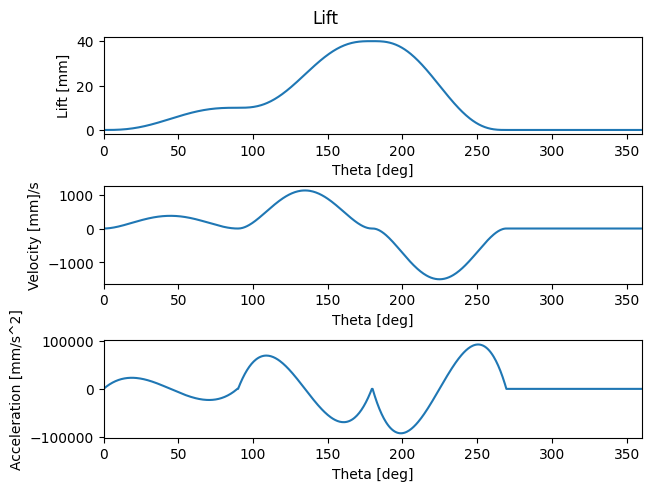

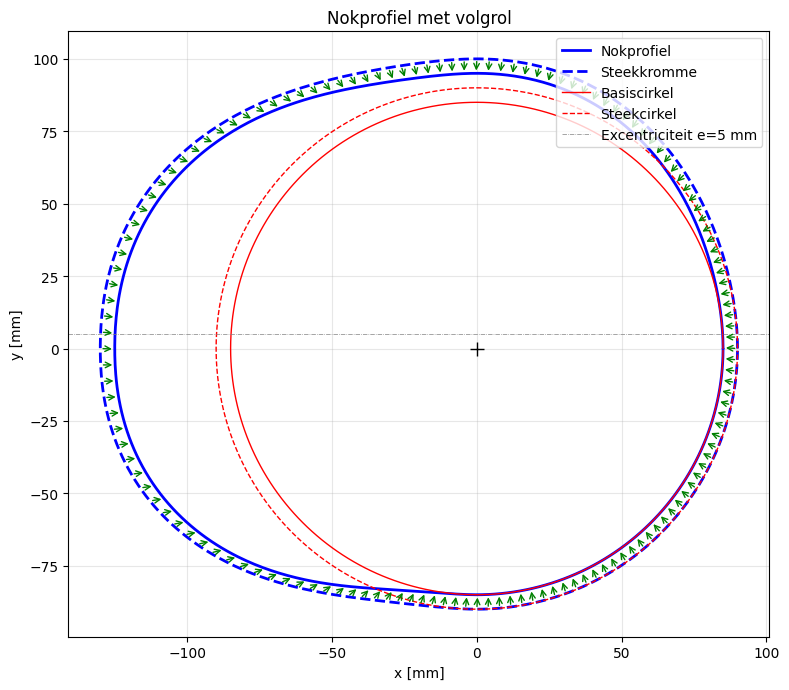

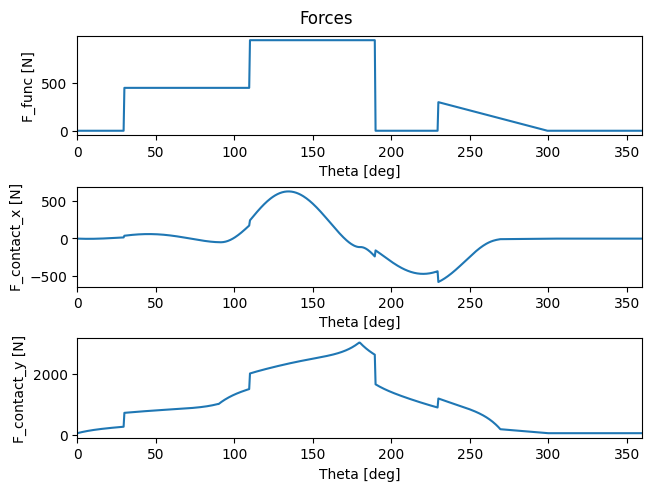

In [96]:
gamma       = 0     # angle between lift and the gravity vector in degrees
m           = 5     # mass of the follower in kg
c           = 0.062 # damping coefficient in N/(mm/s)

n    = 300            # initial angular velocity in rpm
F_v0 = 10           # velocity-dependent force at zero lift in N
R0   = 90             # base circle radius in mm
e    = 5             # excentricity in mm
R_r  = 5             # roller radius in mm

motionlaw = MotionLaw(n=n) 
motionlaw.addMotionSegment(startangle=0,   endangle=90,  startlift=0,  endlift=10, motionlaw=MotionLaw.POLY5)
motionlaw.addMotionSegment(startangle=90,  endangle=180, startlift=10, endlift=40, motionlaw=MotionLaw.POLY5)
motionlaw.addMotionSegment(startangle=180, endangle=270, startlift=40, endlift=0,  motionlaw=MotionLaw.POLY5)
motionlaw.plot()

F_func = np.zeros_like(motionlaw.theta_deg)          # function of angle-dependent forces in N
interval1 = (int(30/motionlaw.dtheta), int(110/motionlaw.dtheta))
interval2 = (int(110/motionlaw.dtheta), int(190/motionlaw.dtheta))
interval3 = (int(230/motionlaw.dtheta), int(300/motionlaw.dtheta))
applySegments(F_func, [(interval1, 450), (interval2, 950), (interval3, (300, 0))])

x_cam, y_cam, F_contact = generateCamProfile(R0=R0, ex=e, R_r=R_r, F_func=F_func, F_v0=F_v0, k_v=50, c=c, m=m, gamma=gamma, motionLaw=motionlaw)
plotCamProfile(R0=R0, ex=e, R_r=R_r, motionLaw=motionlaw, x_cam=x_cam, y_cam=y_cam, arrows=5)

plotForces(motionlaw.theta_deg, [F_func, F_contact[0], F_contact[1]], variable='Theta [deg]', labels=['F_func [N]', 'F_contact_x [N]', 'F_contact_y [N]'])